In [1]:
import lecilab_behavior_analysis.utils as utils
import lecilab_behavior_analysis.df_transforms as dft
import lecilab_behavior_analysis.plots as plots
import lecilab_behavior_analysis.figure_maker as figure_maker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glmhmmt.model import SoftmaxGLMHMM
from pathlib import Path

%load_ext autoreload
%autoreload 2

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
project = "COT_cannula_data"
animals = ['NUO001']#, 'NUO002', 'NUO003', 'NUO004', 'NUO005', 'NUO006', 'NUO007', 'NUO008', 'NUO009', 'NUO010', 'NUO011', 'NUO012']
df_list = []
for mouse in animals:
    local_path = Path(utils.get_outpath()) / Path(project) / Path("sessions") / Path(mouse)
    df_animal = pd.read_csv(local_path / Path(f'{mouse}.csv'), sep=";")
    df_list.append(df_animal)
    print(f"Loaded data for {mouse}.")
# concatenate the dataframes
df_raw = pd.concat(df_list, ignore_index=True)
# clear_output(wait=True)
# time.sleep(.5)
print("Data read successfully.")

/tmp/ipykernel_767695/2464295047.py:6: DtypeWarning: Columns (0: STATE_auto_reward_state_left_END, 1: STATE_auto_reward_state_left_START, 2: STATE_reward_state_left_END, 3: STATE_reward_state_left_START, 4: STATE_reward_state_right_END, 5: STATE_reward_state_right_START) have mixed types. Specify dtype option on import or set low_memory=False.
  df_animal = pd.read_csv(local_path / Path(f'{mouse}.csv'), sep=";")


Loaded data for NUO001.
Data read successfully.


In [3]:
df = dft.analyze_df(df_raw)
print("Dataframe analyzed.")

Dataframe analyzed.


In [4]:
# select the date from 2025-10-10, where it did a few performance oscillations
df_sel = df[df['year_month_day'] == '2025-10-10'].copy()

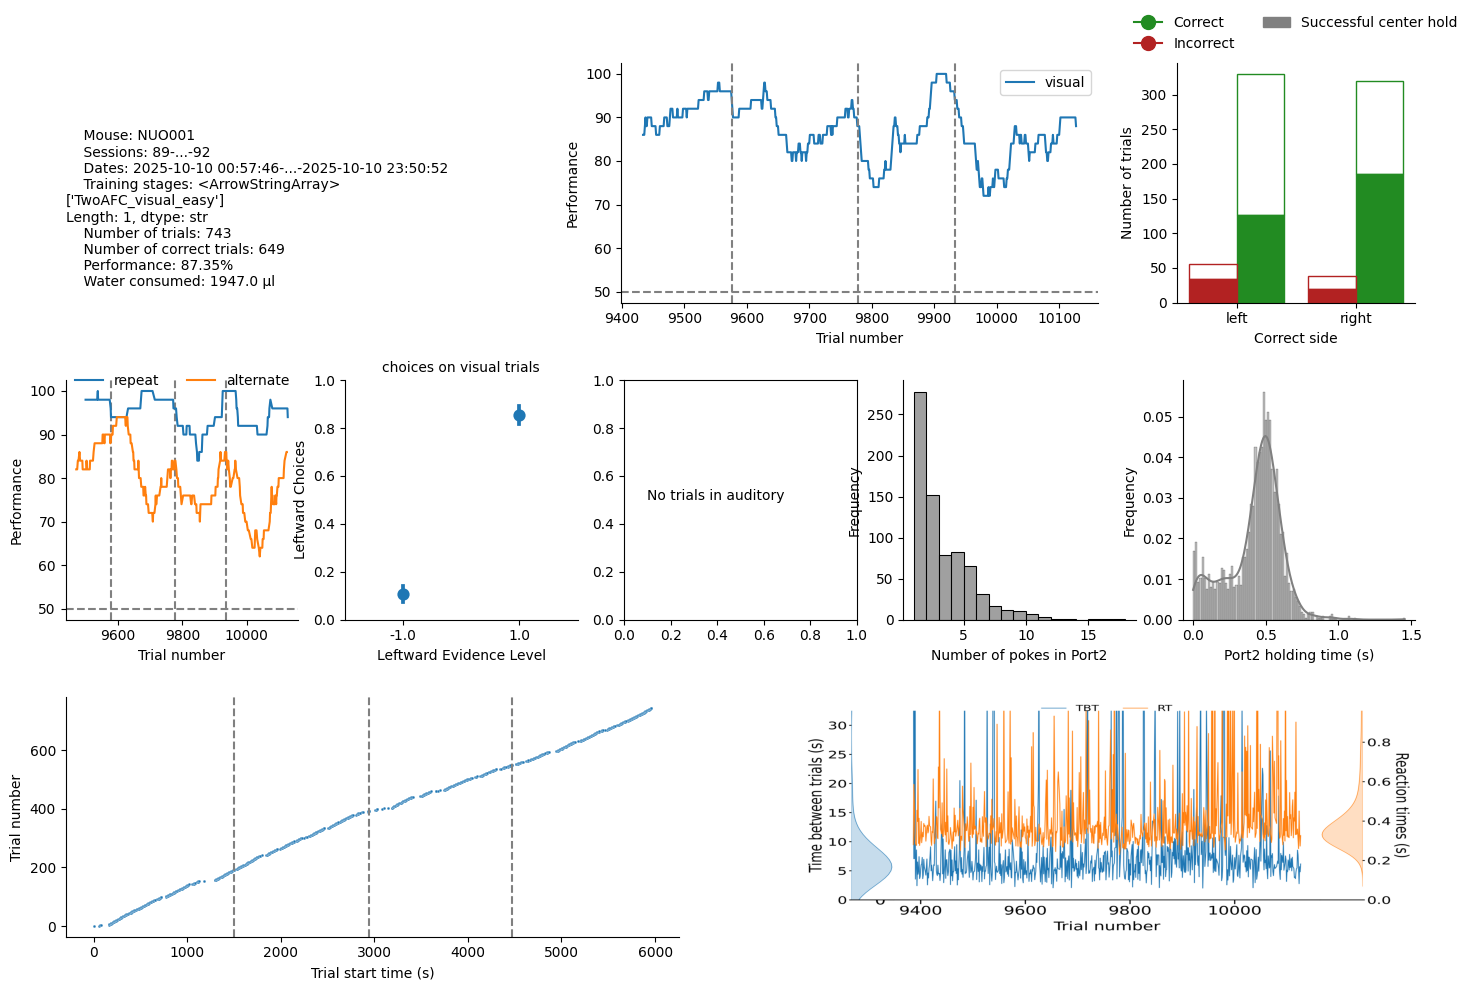

In [5]:
fig = figure_maker.session_summary_figure(df_sel)

In [6]:
import jax.numpy as jnp
import jax.random as jr

In [7]:
df_sel['repeat_or_alternate'] = dft.get_repeat_or_alternate_series(df_sel['first_choice'])

In [8]:
# prepare the data for GLM-HMM fitting to get the probality of going right on each trial
y = df_sel['first_choice'].map({'left': -1, 'right': 1}).values
stimulus_evidence = df_sel['correct_side'].map({'left': -1, 'right': 1}).values
# repeat_or_alternate = df_sel['repeat_or_alternate'].map({'repeat': 1, 'alternate': -1}).values
# get the previous choice using y shifted by 1
previous_choice = np.roll(y, 1)
previous_rewarded = df_sel.correct.map({True: 1, False: 0}).shift(1).values
pRr = (previous_choice == 1) * previous_rewarded
pRu = (previous_choice == 1) * (1 - previous_rewarded)
pLr = (previous_choice == -1) * previous_rewarded
pLu = (previous_choice == -1) * (1 - previous_rewarded)
bias = np.ones_like(y)

inputs = np.column_stack([stimulus_evidence, previous_choice, bias])#, pRr, pRu, pLr, pLu])
inputs_colnames = ['stimulus_evidence', 'previous_choice', 'bias']#, 'pRr', 'pRu', 'pLr', 'pLu']

# delete the first row of inputs and y, since they have NaN values due to the shift
inputs = inputs[1:]
y = y[1:]

# convert to jax arrays
inputs = jnp.array(inputs)
y = jnp.array(y)

In [9]:
num_states = 2
num_classes = 2
emission_input_dim = 3
transition_input_dim = 0

model = SoftmaxGLMHMM(
    num_states=num_states,
    num_classes=num_classes,
    emission_input_dim=emission_input_dim,
    transition_input_dim=transition_input_dim,
    emission_feature_names=inputs_colnames,
    # transition_matrix_stickiness=10
)

In [10]:
params, props = model.initialize()

In [11]:
# fit each session separately
session_ids = df_sel['session'].values[1:] # get the session ids, also delete the first one to match the inputs and y

In [12]:
fitted_params, log_probs = model.fit_em_multisession(
    params,
    props,
    y,
    inputs,
    session_ids=session_ids,
    num_iters=100,
    verbose=True,
)

EM:   0%|          | 0/100 [00:00<?, ?it/s]

In [13]:
fitted_params

ParamsSoftmaxGLMHMM(initial=ParamsStandardHMMInitialState(probs=Array([0.5018439 , 0.49815607], dtype=float32)), transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.1591805 , 0.8408195 ],
       [0.97000784, 0.02999215]], dtype=float32)), emissions=ParamsSoftmaxGLMHMMEmissions(weights=Array([[[-1.035272  , -0.49524522, -9.23794   ]],

       [[-1.0342947 , -0.49172786, -9.062161  ]]], dtype=float32)))

In [14]:
smoothed_probs = model.smoother_multisession(fitted_params, y, inputs, session_ids)
# get only one column
state_one = smoothed_probs[:,0]

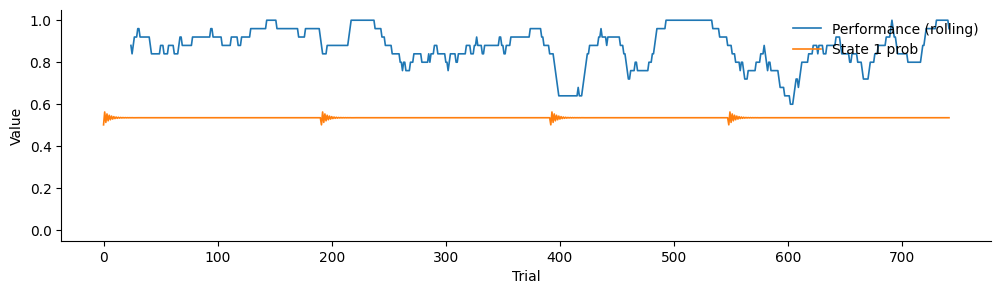

In [15]:
# Performance and state-1 probability in one plot
performance_trace = pd.Series(df_sel["correct"].astype(float).values[1:])
rolled_performance = performance_trace.rolling(window=25).mean()
state_one_np = np.asarray(state_one)

n = min(len(rolled_performance), len(state_one_np))
x = np.arange(n)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(x, rolled_performance.values[:n], color="tab:blue", linewidth=1.2, label="Performance (rolling)")
ax.plot(x, state_one_np[:n], color="tab:orange", linewidth=1.2, label="State 1 prob")
ax.set_xlabel("Trial")
ax.set_ylabel("Value")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper right", frameon=False)
sns.despine()